In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

예측 결과:
 tensor([[0.],
        [1.],
        [1.],
        [1.]])


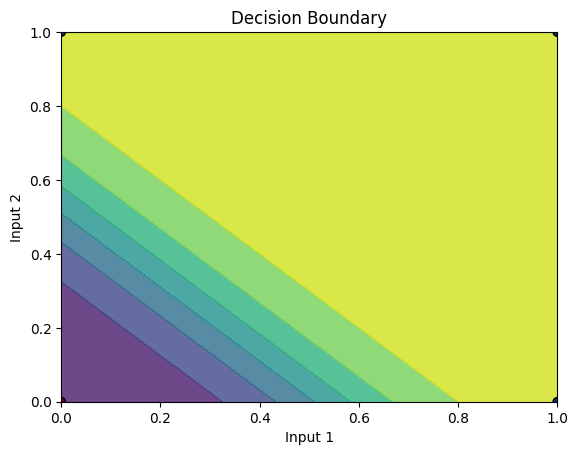

In [17]:
## 1. OR 게이트 학습 및 시각화 (ANN)
# OR gate
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
Y = torch.tensor([[0.], [1.], [1.], [1.]])

# siple ANN
class ORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.fc2 = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

model = ORNet()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# train
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()

# result
with torch.no_grad():
    preds = model(X)
    print("예측 결과:\n", preds.round())

# visualization
def plot_decision_boundary(model):
    xx, yy = torch.meshgrid(torch.linspace(0, 1, 100), torch.linspace(0, 1, 100))
    grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)
    with torch.no_grad():
        Z = model(grid).reshape(xx.shape)
    plt.contourf(xx, yy, Z.numpy(), alpha=0.8)
    plt.scatter(X[:,0], X[:,1], c=Y[:,0], edgecolors='k', cmap=plt.cm.RdBu)
    plt.title("Decision Boundary")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()

plot_decision_boundary(model)

-> 선형분리가 잘 이루어짐.

예측 결과:
 tensor([[1.],
        [1.],
        [0.],
        [0.]])


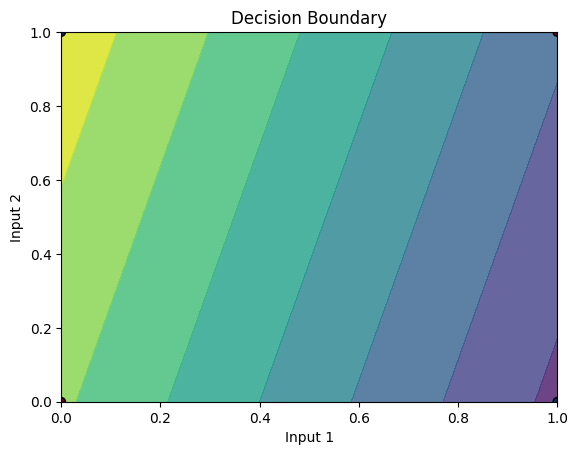

In [18]:
## XOR 게이트 학습 시도 및 한계 시각화 (ANN)
# XOR gate
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
Y = torch.tensor([[0.], [1.], [1.], [0.]])

# simple ANN
model = ORNet()  # 같은 구조 사용

# trian
optimizer = optim.SGD(model.parameters(), lr=0.1)
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()

# result
with torch.no_grad():
    preds = model(X)
    print("예측 결과:\n", preds.round())

plot_decision_boundary(model)

-> XOR의 정답: [0, 1, 1, 0]인데, 여기선 [1, 1, 0, 0]으로 잘못 분류됨. XOR 게이트는 비선형 문제로, hidden layer가 하나인 ANN은 선형 모델로 XOR 게이트의 내부 구조를 꺾어서 나눌 수 없음.

예측 결과:
 tensor([[0.],
        [1.],
        [0.],
        [0.]])


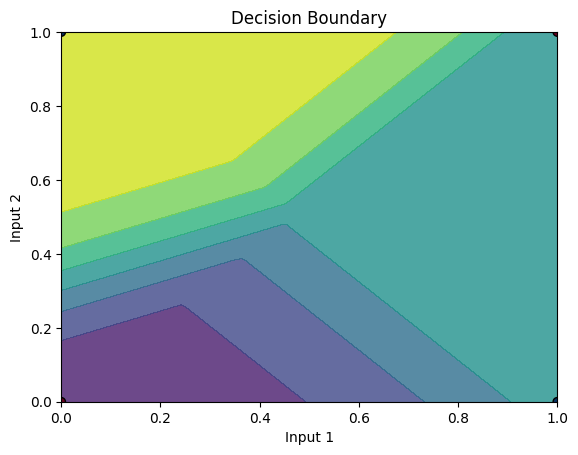

In [19]:
## XOR 게이트 학습 및 시각화 (DNN)
# DNN model
class DNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 4)
        self.fc3 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

model = DNN()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# train
for epoch in range(2000):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()

# result
with torch.no_grad():
    preds = model(X)
    print("예측 결과:\n", preds.round())

plot_decision_boundary(model)


-> 완벽하진 않지만 일부 비선형 구조를 학습한 것으로 보임. 중앙에서 한 번 이상 꺾이며 구조적으로 XOR 분포를 구분하려는 모습. hidden layer가 2개 이상인 덕분에 다양한 형태의 decision boundary를 만들 수 있기 때문.